In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy.stats import linregress
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import warnings
import matplotlib.patches as patches
from scipy.stats import linregress, t
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm
import matplotlib.colors as mcolors
import pickle

import sys

from pathlib import Path

PROJECT_ROOT = Path("/g/korbel/hain/centromere/revision/HOROSCOPE_manuscript")
CLUSTERING_SOURCE = PROJECT_ROOT / "kmer_generation" / "centromere_clustering"
sys.path.insert(0, str(CLUSTERING_SOURCE))

from config import CLUSTER_IDS_BY_CHROMOSOME, make_config # type: ignore
from length import correlation_analysis, count_hor, reverse_complement # type: ignore

warnings.filterwarnings("ignore")

from build_datasheets import gather_cluster_and_hor_haplotype, squash_sample_haplotypes
from normalization import normalize # type: ignore
from prediction import count_present_kmer_fraction, build_asm_prediction_dataframe # type: ignore

# Parameter

In [ ]:
### chromosome to work on
chrom = "chr8"

### config file with several paths, from clustering 
clustering_config = make_config(chrom)

### samplesheet with active centromeres, based on chromosome
df = pd.read_csv("/g/korbel/hain/centromere/samplesheets/centromeres_full.tsv", sep="\t")
active_centromeres = df[(df["CHROM"] == chrom) & (df["ACTIVE"] == True)].copy().reset_index(drop=True)

### Path to cluster assignments
cluster_assignments_path = f"/g/korbel/hain/centromere/tagging_kmers_new/{chrom}_sample_cluster_assignment.tsv"

### km data file
km_data_file_path = f"/scratch/hain/centromere/rerun_1kgp/final_kmer_merged.{chrom}_1kgp.tsv"

### All samples in panel
samples = active_centromeres["SAMPLE"].unique()

### List samples used for testing (not used for model training)
rng = np.random.default_rng(seed=10)
test_samples = rng.choice(
    np.asarray(samples),
    size=int(len(samples) * 0.20),
    replace=False,
).tolist()
train_samples = np.setdiff1d(samples, test_samples)


## Build dataframe with length and cluster assignments for individual haplotypes and aggregate per sample

In [31]:
hp_dataframe = gather_cluster_and_hor_haplotype(active_centromeres=active_centromeres, samples=samples, chrom=chrom, clustering_config=clustering_config) # type: ignore
squashed_hp_dataframe = squash_sample_haplotypes(sample_information=hp_dataframe, samples=samples, chrom=chrom) # type: ignore

Number of samples: 282
Number of samples with complete information: 270


# Load KM kmer data from file

In [32]:
km_df = pd.read_csv(km_data_file_path, sep="\t")

# Samples with assemblies and KM values

In [33]:
km_samples = sorted(list(set(list(squashed_hp_dataframe.index)).intersection(set(km_df.columns))))
km_samples_test = np.intersect1d(km_samples, test_samples)
km_samples_train = np.setdiff1d(km_samples, km_samples_test)

# Plot coverage

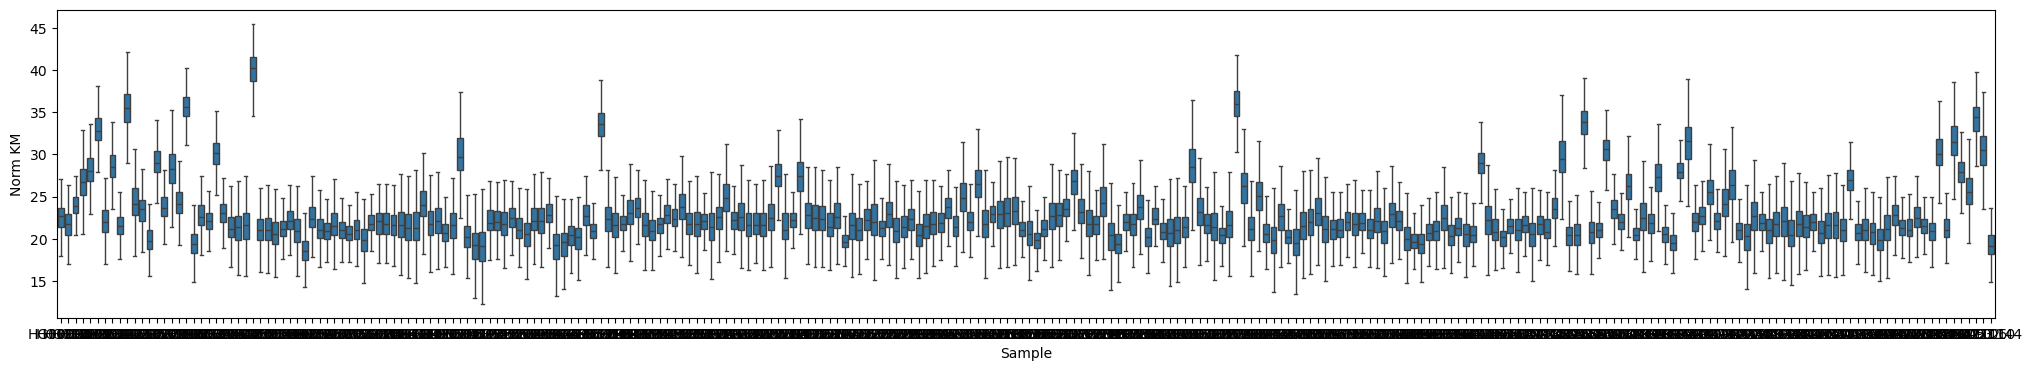

In [34]:
fig, ax= plt.subplots(figsize=(25, 4))
sns.boxplot(
    data=km_df[km_df["CLUSTER"].str.contains(f"{chrom}_NORM")][km_samples].melt(var_name="Sample", value_name="Norm KM"),
    x="Sample",
    y="Norm KM",
    showfliers=False,
    ax=ax,
)
plt.show()
plt.close()

# Normalize KM values

In [35]:
mode = "ALL"
if chrom in ["chr21"]:
    mode = "UNITIG"

km_df_norm = normalize (kmer_df=km_df, chrom=chrom, mode=mode, samples=km_samples)

# Plot coverage after normalization

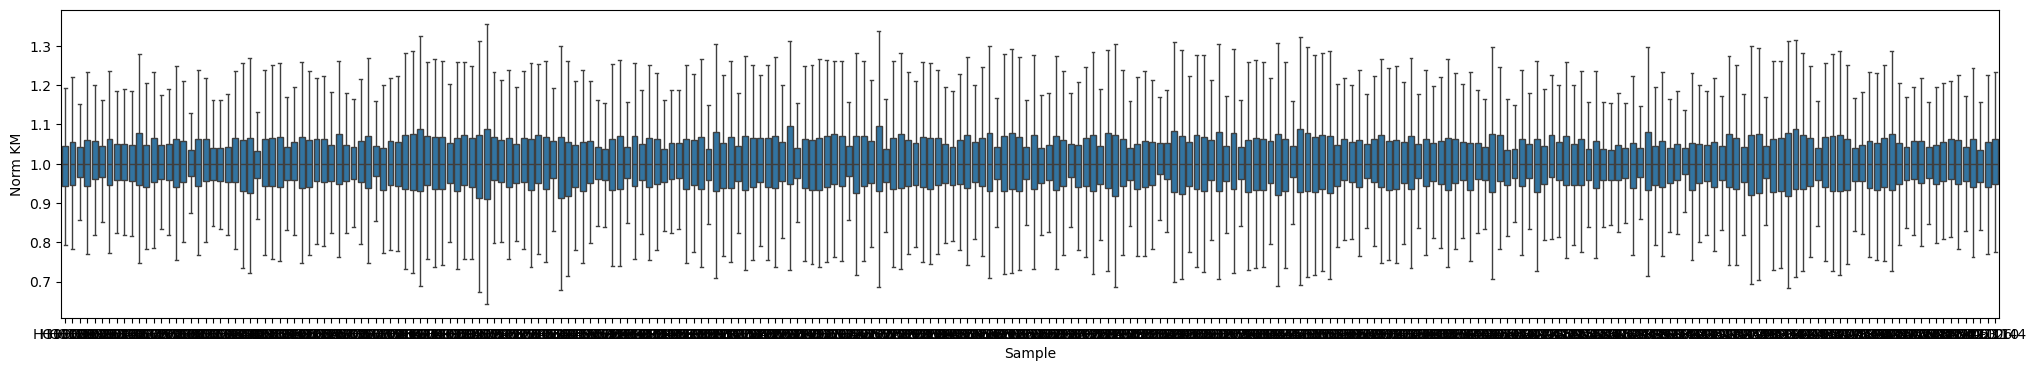

In [36]:
fig, ax= plt.subplots(figsize=(25, 4))
sns.boxplot(
    data=km_df_norm[km_df_norm["CLUSTER"].str.contains(f"{chrom}_NORM")][km_samples].melt(var_name="Sample", value_name="Norm KM"),
    x="Sample",
    y="Norm KM",
    showfliers=False,
    ax=ax,
)
plt.show()
plt.close()

# Predict centromere clusters

In [37]:
### count fraction of cluster specific kmers found per sample
predictions = count_present_kmer_fraction (normed_kmer_df=km_df_norm, samples=km_samples, chrom=chrom, clusters=CLUSTER_IDS_BY_CHROMOSOME[chrom]).set_index("SAMPLE")

In [38]:
### build table with cluster usage from assemblies
asm_predictions = build_asm_prediction_dataframe(sample_hp_cluster_df=squashed_hp_dataframe, samples=km_samples, clusters=predictions.columns, chrom=chrom).set_index("SAMPLE")

## Compare prediction with ground truth visually

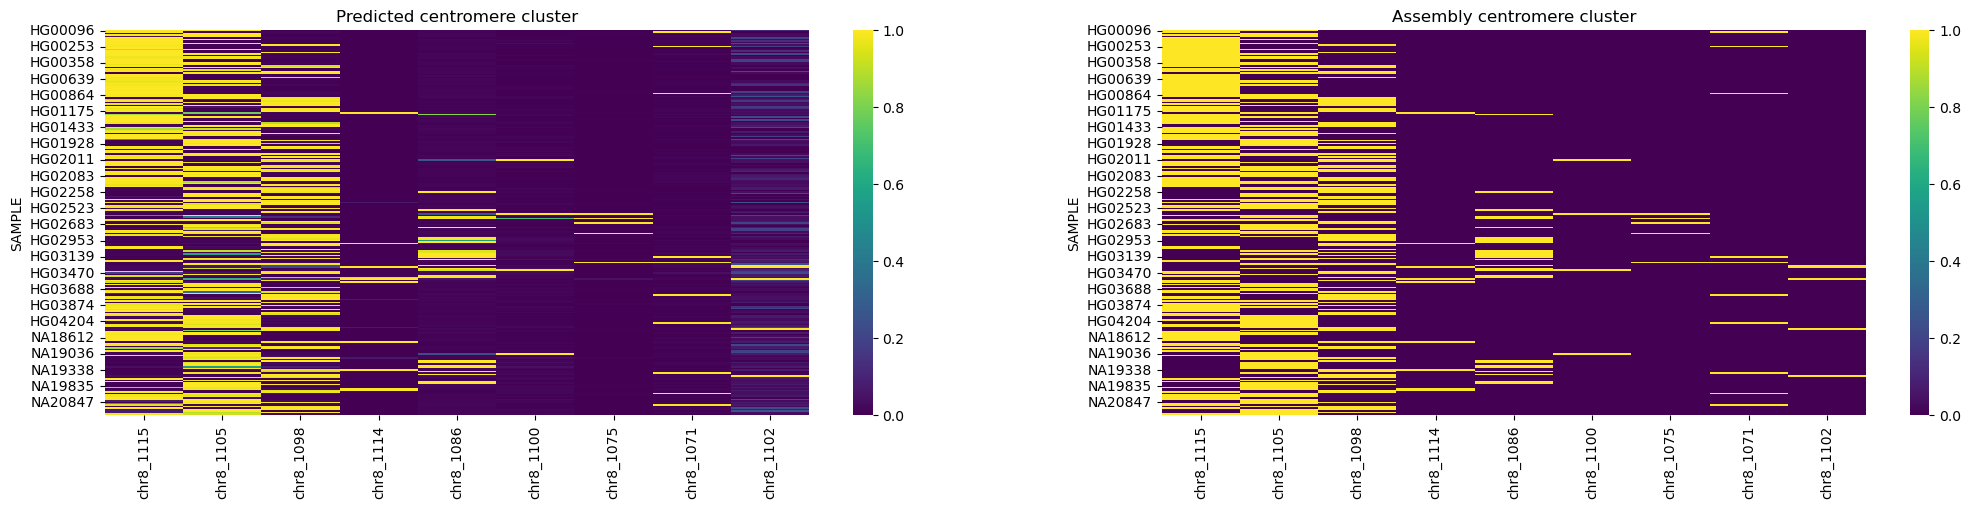

In [39]:
### plot predicted and assembly centromere cluster heatmaps side by side

ax_prediction = plt.subplot(1, 2, 1)
sns.heatmap(predictions, annot=False, cmap='viridis', fmt='.2f', cbar=True, ax=ax_prediction)
ax_prediction.set_title("Predicted centromere cluster")

ax_asm_prediction = plt.subplot(1, 2, 2)
sns.heatmap(asm_predictions, annot=False, cmap='viridis', fmt='.2f', cbar=True, ax=ax_asm_prediction)
ax_asm_prediction.set_title("Assembly centromere cluster")

plt.gcf().set_size_inches((25, 5))
plt.show()

In [40]:
def calculate_metrics(asm_predictions, predictions, cutoff):
    ### calculate precision, accuracy, recall
    
    # true positive asm_pred >= 1 & pred >= cutoff
    tp = ((asm_predictions >= 1) & (predictions >= cutoff)).sum().sum()
    # false positive asm_pred < 1 & pred >= cutoff
    fp = ((asm_predictions < 1) & (predictions >= cutoff)).sum().sum()
    # true negative asm_pred < 1 & pred < cutoff
    tn = ((asm_predictions < 1) & (predictions < cutoff)).sum().sum()
    # false negative asm_pred >= 1 & pred < cutoff
    fn = ((asm_predictions >= 1) & (predictions < cutoff)).sum().sum()
    
    # accuracy
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    # recall
    recall = tp / (tp + fn)
    # precision
    precision = tp / (tp + fp) 
    
    return {"TP": tp, "FP": fp, "TN": tn, "FN": fn, "ACCURACY": accuracy, "RECALL": recall, "PRECISION": precision}

In [41]:
all = calculate_metrics(asm_predictions.loc[km_samples], predictions.loc[km_samples], cutoff=0.5)
all["GROUP"] = "ALL"
train = calculate_metrics(asm_predictions.loc[km_samples_train], predictions.loc[km_samples_train], cutoff=0.5)
train["GROUP"] = "TRAIN"
test = calculate_metrics(asm_predictions.loc[km_samples_test], predictions.loc[km_samples_test], cutoff=0.5)
test["GROUP"] = "TEST"

pd.DataFrame([all, train, test])

,TP,FP,TN,FN,ACCURACY,RECALL,PRECISION,GROUP
0,438,3,1915,2,0.997880,0.995455,0.993197,ALL
1,356,3,1547,2,0.997379,0.994413,0.991643,TRAIN
2,82,0,368,0,1.000000,1.000000,1.000000,TEST


### Number of het, hom and unpredicted samples

In [42]:
pd.DataFrame(
    [{
        "HOM": (asm_predictions.sum(axis=1) == 1).sum(),
        "HET": (asm_predictions.sum(axis=1) == 2).sum(),
        "UNPREDICTED": 272 - (asm_predictions.sum(axis=1) == 1).sum() - (asm_predictions.sum(axis=1) == 2).sum()
    }]
)

,HOM,HET,UNPREDICTED
0,84,178,10


# Length prediction

### transpose and reformat KM dataframe and add HOR length to prepare for length prediction

In [43]:
### subset to length kmers, remove cluster column and transpose
km_df_norm_length = km_df_norm[km_df_norm["CLUSTER"] == "chr8_HOR"].set_index("KMER").drop(["CLUSTER"], axis=1).T

### save length kmer set
length_kmers = km_df_norm_length.columns

### add HOR length per sample
col_mean_hor_length = []
for sample in km_df_norm_length.index: # type: ignore
    col_mean_hor_length.append(squashed_hp_dataframe.loc[sample, f"{chrom}_MEAN_HOR_LENGTH"])
km_df_norm_length["HOR_LENGTH"] = col_mean_hor_length

### split into train and test dataframes

In [44]:
km_df_norm_length_train = km_df_norm_length.loc[km_samples_train]
km_df_norm_length_test = km_df_norm_length.loc[km_samples_test]

### check correlation for each kmer and remove bad kmers

In [45]:
### empty dataframe to store correlation data
tmp_corr_data = {"KMER":[], "R":[]}

### calculate correlation for each kmer
for kmer in tqdm(length_kmers):
    tmp_corr_data["KMER"].append(kmer)
    tmp_corr_data["R"].append(correlation_analysis (km_df_norm_length[kmer].tolist(), km_df_norm_length["HOR_LENGTH"].tolist()))
    
    corr_df = pd.DataFrame(tmp_corr_data)
    
corr_df = pd.DataFrame(tmp_corr_data)

### select kmers with high correlation, remove either kmers with R below 0.7 or remove the worst 25% of kmers
selected_length_kmers = corr_df.loc[corr_df["R"] >= np.amax([0.7, np.quantile(corr_df["R"], 0.25)]), "KMER"].tolist() # type: ignore

100%|██████████| 1988/1988 [00:01<00:00, 1315.55it/s]


## Build model for total length prediction

In [65]:
dict_length_pca = {}
dict_length_linregress = {}
dict_length_kmers = {}

In [48]:
### build train and test data
X_train = km_df_norm_length.loc[km_samples_train][selected_length_kmers]
y_train = km_df_norm_length.loc[km_samples_train]["HOR_LENGTH"]
X_test = km_df_norm_length.loc[km_samples_test][selected_length_kmers]
y_test = km_df_norm_length.loc[km_samples_test]["HOR_LENGTH"]

In [49]:
### build pca
pca = PCA(n_components=2)
reduced_X_train = pca.fit_transform(X_train)
reduced_X_test = pca.transform(X_test)

In [50]:
# build linear model
model = LinearRegression()
model.fit(reduced_X_train, y_train)
y_pred_train = model.predict(reduced_X_train)
y_pred_test = model.predict(reduced_X_test)

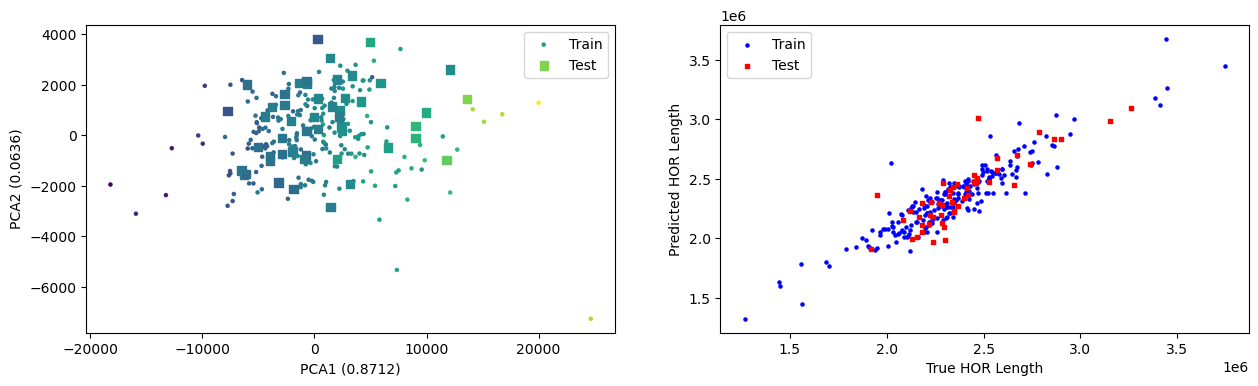

In [51]:
### Plot PCA and LinReg
ax_pca = plt.subplot(1, 2, 1)
ax_pca.scatter(reduced_X_train[:, 0], reduced_X_train[:, 1], c=y_train, cmap="viridis", vmin=np.amin([y_train.min(), y_test.min()]), vmax=np.amax([y_train.max(), y_test.max()]), marker="o", s=5, label="Train")
ax_pca.scatter(reduced_X_test[:, 0], reduced_X_test[:, 1], c=y_test, cmap="viridis", vmin=np.amin([y_train.min(), y_test.min()]), vmax=np.amax([y_train.max(), y_test.max()]), marker="s", label="Test")
ax_pca.set_xlabel(f"PCA1 ({np.round(pca.explained_variance_ratio_[0], 4)})")
ax_pca.set_ylabel(f"PCA2 ({np.round(pca.explained_variance_ratio_[1], 4)})")
ax_pca.legend()

ax_linreg = plt.subplot(1, 2, 2)
ax_linreg.scatter(y_train, y_pred_train, c="blue", marker="o", s=5, label="Train")
ax_linreg.scatter(y_test, y_pred_test, c="red", marker="s", s=5, label="Test")
ax_linreg.set_xlabel("True HOR Length")
ax_linreg.set_ylabel("Predicted HOR Length")
ax_linreg.legend()

plt.gcf().set_size_inches((15, 4))
plt.show()

In [52]:
### Evaluate model
from sklearn.metrics import mean_squared_error, r2_score
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
print(f"Train MSE: {mse_train}, R2: {r2_train}")
print(f"Test MSE: {mse_test}, R2: {r2_test}")

Train MSE: 14125924604.387037, R2: 0.8703373034371995
Test MSE: 21469376357.2679, R2: 0.6918757283649792


In [67]:
dict_length_pca[f"{chrom}_HOR"] = pca
dict_length_linregress[f"{chrom}_HOR"] = model
dict_length_kmers[f"{chrom}_HOR"] = selected_length_kmers

# Save kmer sets and models to file

In [68]:
model_save_folder = "/g/korbel/hain/centromere/tagging_kmers/models_new/"

In [71]:
with open(f"{model_save_folder}{chrom}_pca.pkl", "wb") as f:
    pickle.dump(dict_length_pca, f)
with open(f"{model_save_folder}{chrom}_linreg.pkl", "wb") as f:
    pickle.dump(dict_length_linregress, f)
with open(f"{model_save_folder}{chrom}_len_kmers.pkl", "wb") as f:
    pickle.dump(dict_length_kmers, f) 